# 🍳 What Can I Cook Tonight? — Bayesian LDA Recipe Recommender

A **fully Bayesian** Latent Dirichlet Allocation recommender built on **PyMC + NUTS**.
Given the ingredients you have on hand, it returns the Top-N recipes you can make, ranked by
a composite score that fuses *coverage*, *latent-flavor alignment*, and a *Bayesian-smoothed
rating* — with uncertainty propagated from the MCMC posterior all the way to the ranking.

This notebook organizes the **model-construction flow** end to end:

1. **`train_lda`** — Bayesian LDA over latent "flavor topics" (NUTS; *z* marginalized); K by held-out predictive likelihood
2. **`filter_candidates`** — keep recipes you can actually make (ingredient coverage)
3. **`infer_user_posterior`** — Bayesian posterior over flavor topics for an ingredient set
4. **`score_recipes`** — composite Bayesian score using the *full* posterior
5. **`recommend`** — Top-N recipes

> The final model is **already trained and cached** in `models/lda_model.pkl` (K = 6). This
> notebook **loads** it (fast); the training cell shows exactly how it was produced.

## 0 · Setup

The first cell points the working directory at the `model/` root and puts `src/` on the path,
so `import recipe_recommender` and the `data/ models/ figures/` paths resolve.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":     # launched from model/notebooks/
    os.chdir("..")                                   # -> model/
sys.path.insert(0, os.path.join(os.getcwd(), "src")) # so `import recipe_recommender` works

import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

import recipe_recommender as rr      # the model + 5 pipeline functions  (src/)
import visualize as viz              # plotting helpers (save PNGs we then display)

pd.set_option("display.max_colwidth", 55)
df = pd.read_csv("data/recipes_clean.csv")
print(f"{len(df):,} recipes loaded")
df.head(3)

g++ not available, if using conda: `conda install gxx`


53,573 recipes loaded


,recipe_id,recipe_name,ingredients,avg_rating,n_ratings
0,75452,beat this banana bread,"[""sugar"", ""unsalted butter"", ""banana"", ""egg"", ""lemo...",4.4,5
1,42198,better than sex strawberries,"[""vanilla wafer"", ""butter"", ""powdered sugar"", ""egg""...",3.8,5
2,67547,better then bush s baked beans,"[""great northern bean"", ""chicken bouillon cube"", ""d...",3.9,10


## 1 · The data

Food.com recipes cleaned by `src/prepare_data.py` (>= 5 ratings, 2-35 ingredients, ingredient
names normalized). Columns: `recipe_id, recipe_name, ingredients` (JSON list), `avg_rating,
n_ratings`. Ingredient names are already canonicalized, so the coverage set-intersections in
Step 2 are meaningful.

In [2]:
ex = df.iloc[0]
print("recipe     :", ex["recipe_name"])
print("ingredients:", json.loads(ex["ingredients"]))
df[["avg_rating", "n_ratings"]].describe().round(2)

recipe     : beat this  banana bread
ingredients: ['sugar', 'unsalted butter', 'banana', 'egg', 'lemon juice', 'orange rind', 'cake flour', 'baking soda', 'salt']


,avg_rating,n_ratings
count,53573.00,53573.00
mean,4.45,15.14
std,0.53,34.48
min,0.00,5.00
25%,4.20,6.00
50%,4.58,8.00
75%,4.83,14.00
max,5.00,1613.00


## 2 · The Bayesian model

Classic LDA draws a *discrete* topic per token, $z_{mn}\sim\text{Categorical}(\theta_m)$. NUTS
is gradient-based and cannot move over discrete latents, so we **marginalize $z$ analytically** —
each ingredient token is then Categorical with probability vector $\theta_m\,\phi$:

$$\phi_k \sim \text{Dirichlet}(\beta=0.01),\qquad
  \theta_m \sim \text{Dirichlet}(\alpha=0.1),\qquad
  w_{mn} \sim \text{Categorical}(\theta_m\,\phi)$$

This is the *same* model with $z$ integrated out, leaving only continuous simplices for NUTS.
We keep the **full posterior** of $\phi$ (samples, not a point estimate) — that is what lets
every downstream quantity carry uncertainty.

```python
with pm.Model() as m:                                  # in recipe_recommender._fit_one_k
    phi   = pm.Dirichlet("phi",   a=0.01*np.ones(V), shape=(K, V))
    theta = pm.Dirichlet("theta", a=0.1 *np.ones(K), shape=(M, K))
    p = pm.math.dot(theta, phi)                         # (M, V)  -- z marginalized
    pm.Categorical("w", p=p[doc_idx], observed=word_idx)
```

## 3 · Step 1 — `train_lda`: fit + choose K out-of-sample

`K` is chosen by **held-out predictive log-likelihood** (15% of ingredient tokens held out).
In-sample WAIC / PSIS-LOO keep improving as K grows (overfitting), so they are reported only as
diagnostics. Below we **load the cached K = 6 model**; the `else` branch shows how it was trained
(a single NUTS fit, since one K means no sweep).

In [3]:
if os.path.exists("models/lda_model.pkl"):
    model = rr.load_model("models/lda_model.pkl")     # the already-trained final model
    print("Loaded cached model. K =", model.best_k)
else:
    model = rr.train_lda(df, k_values=(6,), n_train=400, vocab_size=100,
                         draws=300, tune=400, chains=2, seed=42)   # ~one NUTS fit
    rr.save_model(model, "models/lda_model.pkl")

rr._STATE = {"model": model, "df_id": id(df)}          # let recommend() reuse it
print("vocab size :", len(model.vocab), "| posterior samples:", model.n_samples)

Loaded cached model. K = 6
vocab size : 100 | posterior samples: 300


In [4]:
print("Diagnostics for the chosen K (held-out is NaN for a single K):")
display(model.waic_table.round(2))
print(f"ESS(phi, chain 0): min={model.ess_min:.0f}, median={model.ess_median:.0f}\n")
print("Flavor topics:")
for k, lab in enumerate(model.topic_labels):
    print(f"  topic {k}: {lab:<40s} P(topic)={model.topic_prior[k]:.3f}")

Diagnostics for the chosen K (held-out is NaN for a single K):


,K,heldout_lppd,waic,p_waic,elpd_loo,p_loo,pct_bad_k
0,6,NaN,17134.65,618.82,-8573.88,625.37,0.38


ESS(phi, chain 0): min=1, median=6

Flavor topics:
  topic 0: onion / salt / sour cream                P(topic)=0.154
  topic 1: flour / egg / salt                       P(topic)=0.154
  topic 2: sugar / flour / egg                      P(topic)=0.184
  topic 3: water / salt / sugar                     P(topic)=0.117
  topic 4: onion / salt / garlic clove              P(topic)=0.207
  topic 5: olive oil / garlic clove / black pepper  P(topic)=0.184


### Why K is chosen out-of-sample

Held-out predictive lppd peaks at a small K, while in-sample WAIC / LOO keep "improving" with K
— the classic overfitting signature (a large `p_waic`/`p_loo` and many Pareto-$k$ above
threshold flag that the in-sample penalty is no longer trustworthy). From a full K-sweep
(`model_selection.json`).

wrote figures/fig1_model_selection.png


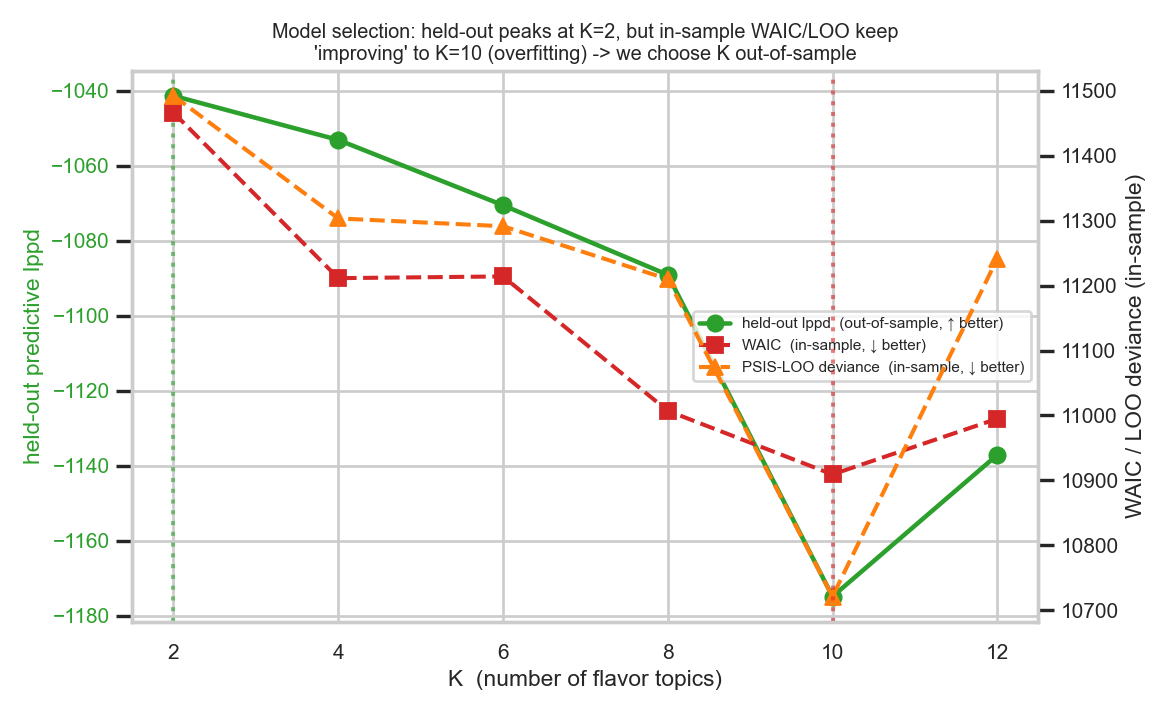

In [5]:
viz.fig_model_selection("figures/fig1_model_selection.png")
Image("figures/fig1_model_selection.png")

## 4 · The fitted topics — posterior over $\phi$

The "fully Bayesian" view: each topic's top ingredients with **94% credible intervals** on
$\phi = P(\text{ingredient}\mid\text{topic})$. We keep distributions, not point estimates.

wrote figures/fig2_topic_phi_posterior.png


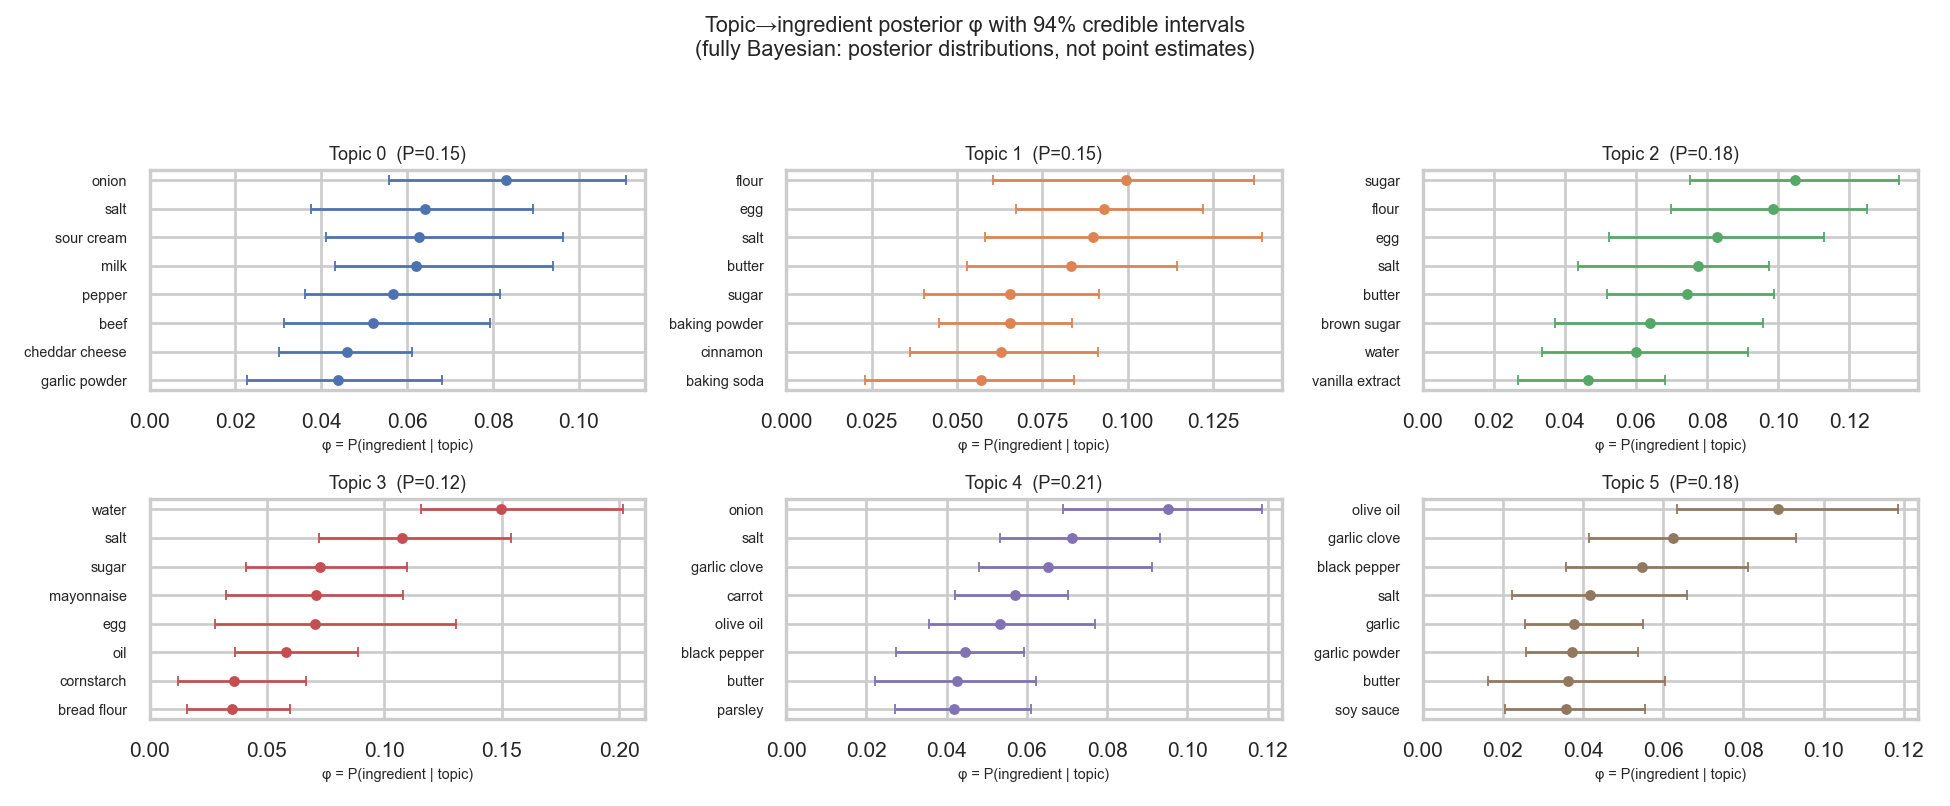

In [6]:
viz.fig_topic_phi("figures/fig2_topic_phi_posterior.png")
Image("figures/fig2_topic_phi_posterior.png")

## 5 · Steps 2-5 — the recommendation pipeline

- **`filter_candidates`** — $\text{coverage}=|U\cap R|/|R|$, keep $\ge 0.7$ (relax to $0.5$).
- **`infer_user_posterior`** — Bayes *per posterior sample*: $P(k\mid\text{ingr})\propto\big(\prod_i\phi[k,i]\big)\,P(k)$.
- **`score_recipes`** — $\text{coverage}^2\cdot\text{overlap\_bonus}\cdot\text{alignment}\cdot\text{rating}$; alignment and its uncertainty come from the posterior.
- **`recommend`** — Top-N.

In [7]:
ITAL = ["chicken", "garlic", "onion", "olive oil", "tomato", "basil",
        "parmesan cheese", "pasta", "salt", "pepper"]
cols = ["recipe_name", "score", "coverage", "predicted_rating", "posterior_uncertainty"]
pd.DataFrame(rr.recommend(ITAL, df))[cols]

[filter_candidates] threshold=0.7: 53 candidate recipes


,recipe_name,score,coverage,predicted_rating,posterior_uncertainty
0,tomato sandwich from italy,2.6572,6/7 ingredients,4.803,0.1152
1,pasta with oil and garlic sauce,2.2779,5/6 ingredients,4.625,0.0211
2,garlicky tomato bruschetta,2.2558,5/6 ingredients,4.634,0.0556
3,fresh mozzarella tomato basil salad,2.1963,5/6 ingredients,4.515,0.0796
4,tomato basil pizza sauce,2.1953,5/6 ingredients,4.446,0.0262


### Step 3 — the user's flavor posterior

$P(\text{topic}\mid\text{pantry})$ with 94% credible intervals. A pantry can collapse onto one
topic (certain) or split across two (genuinely uncertain) — same machinery, different certainty.

wrote figures/fig3_user_topic_posterior.png


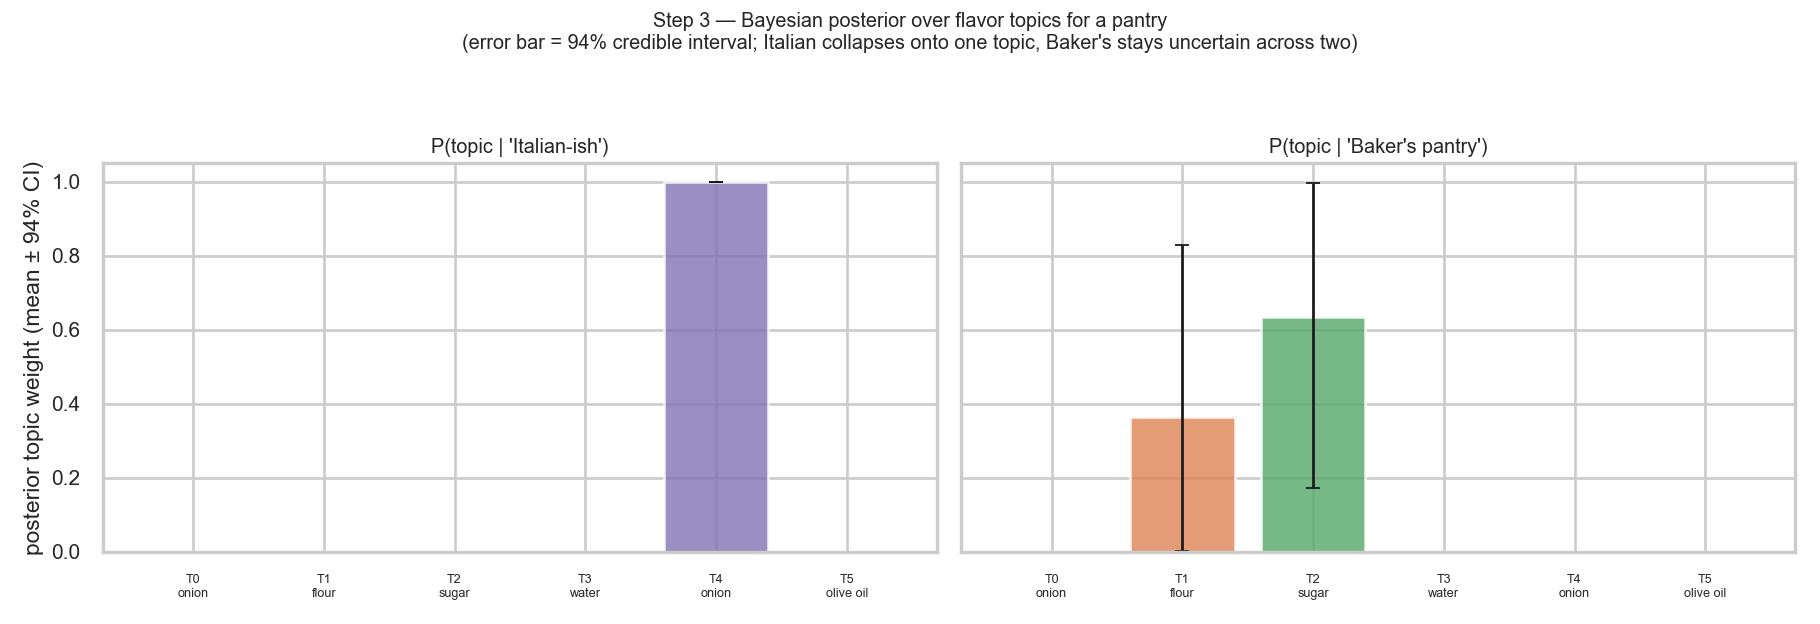

In [8]:
viz.fig_user_posterior("figures/fig3_user_topic_posterior.png")
Image("figures/fig3_user_topic_posterior.png")

### Uncertainty propagated into the ranking

Per-MCMC-sample flavor alignment for the Top-5 — the $\phi$ posterior's uncertainty reaches the
final score.

[filter_candidates] threshold=0.7: 53 candidate recipes
[filter_candidates] threshold=0.7: 53 candidate recipes


wrote figures/fig4_recommendation_uncertainty.png


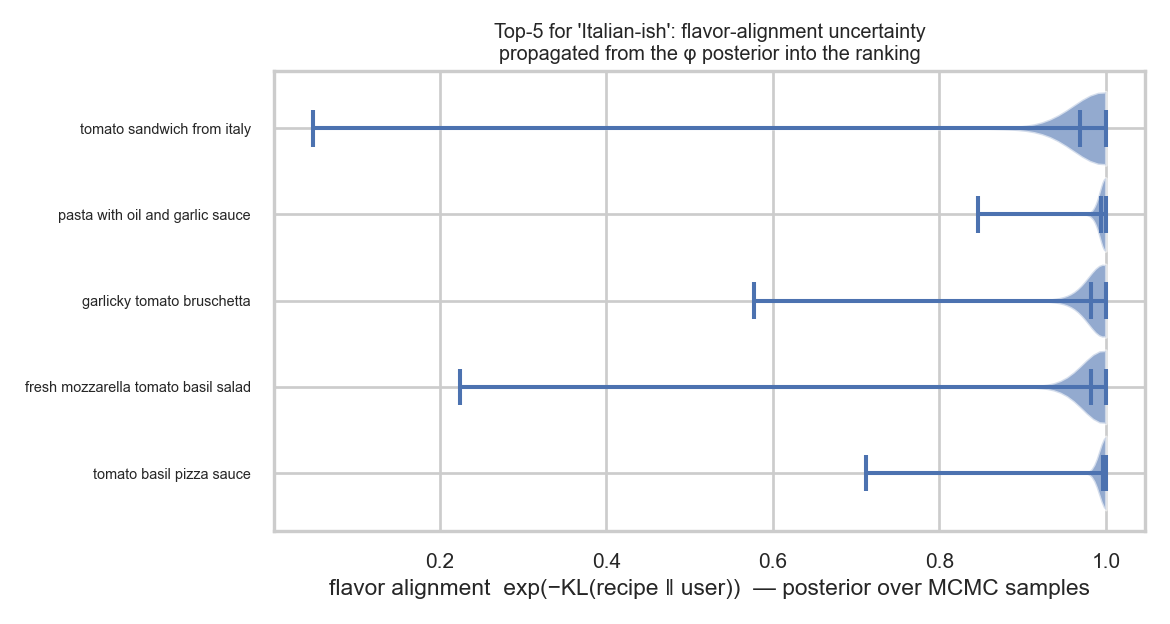

In [9]:
viz.fig_reco_uncertainty("figures/fig4_recommendation_uncertainty.png")
Image("figures/fig4_recommendation_uncertainty.png")

## 6 · User-facing options

`recommend(..., top_n=, exclude=, must_use=, diet=, diversity=)`.

In [10]:
veg = rr.recommend(ITAL, df, diet="vegetarian", must_use=["tomato"], top_n=5)
print("vegetarian + must-use tomato:")
pd.DataFrame(veg)[cols]

[filter_candidates] threshold=0.7: 53 candidate recipes
[filters] diet=vegetarian, must_use=['tomato']: 53 -> 16 recipes
vegetarian + must-use tomato:


,recipe_name,score,coverage,predicted_rating,posterior_uncertainty
0,tomato sandwich from italy,2.6572,6/7 ingredients,4.803,0.1152
1,garlicky tomato bruschetta,2.2558,5/6 ingredients,4.634,0.0556
2,fresh mozzarella tomato basil salad,2.1963,5/6 ingredients,4.515,0.0796
3,baked parmesan tomatoes,2.1792,5/6 ingredients,4.524,0.0748
4,balsamic tomato basil pasta,1.8324,7/10 ingredients,4.528,0.0028


In [11]:
BAKE = ["flour", "sugar", "butter", "egg", "vanilla", "baking soda",
        "milk", "salt", "chocolate"]
print("diversity=0.6 (MMR re-rank for variety):")
pd.DataFrame(rr.recommend(BAKE, df, diversity=0.6, top_n=5))[cols]

diversity=0.6 (MMR re-rank for variety):


[filter_candidates] threshold=0.7: 725 candidate recipes


,recipe_name,score,coverage,predicted_rating,posterior_uncertainty
0,strawberry jam tarts cookies,3.2812,8/9 ingredients,4.803,0.0000
1,amish friendship starter,1.7917,3/3 ingredients,4.779,0.2826
2,pancake souffle,2.6671,5/5 ingredients,4.458,0.1684
3,pikelets australian pancakes,3.0636,7/8 ingredients,4.874,0.0101
4,eat sum more shortbread cookies,1.0923,3/4 ingredients,4.686,0.2271


## 7 · Your final model — how to use it

The fitted posterior is saved in **`models/lda_model.pkl`** (K = 6). To use it (from `model/`,
with `src/` on the path):

In [12]:
import sys; sys.path.insert(0, "src")
import pandas as pd, recipe_recommender as rr

df = pd.read_csv("data/recipes_clean.csv")
model = rr.load_model("models/lda_model.pkl")     # <-- your final model
rr._STATE = {"model": model, "df_id": id(df)}     # so recommend() reuses it (no retrain)

rr.recommend(["egg", "flour", "sugar", "butter", "milk", "vanilla"], df, top_n=5)

[filter_candidates] threshold=0.7: 203 candidate recipes


[{'recipe_name': 'pancake souffle',
  'score': 3.1049,
  'coverage': '5/5 ingredients',
  'missing_ingredients': [],
  'flavor_tags': ['sugar / flour / egg', 'flour / egg / salt'],
  'predicted_rating': 4.458,
  'posterior_uncertainty': 0.0381},
 {'recipe_name': 'crustless baked custard pie',
  'score': 2.5667,
  'coverage': '6/7 ingredients',
  'missing_ingredients': ['salt'],
  'flavor_tags': ['sugar / flour / egg', 'flour / egg / salt'],
  'predicted_rating': 4.508,
  'posterior_uncertainty': 0.0034},
 {'recipe_name': 'pennsylvania dutch breakfast cake',
  'score': 2.5518,
  'coverage': '6/7 ingredients',
  'missing_ingredients': ['baking powder'],
  'flavor_tags': ['sugar / flour / egg', 'flour / egg / salt'],
  'predicted_rating': 4.624,
  'posterior_uncertainty': 0.0462},
 {'recipe_name': 'german cheesecake',
  'score': 2.5029,
  'coverage': '6/7 ingredients',
  'missing_ingredients': ['cream cheese'],
  'flavor_tags': ['sugar / flour / egg', 'onion / salt / sour cream'],
  'pred

## Summary

- **Model:** fully Bayesian LDA (NUTS, $z$ marginalized), **K = 6** flavor topics, full $\phi$ posterior.
- **Selection:** out-of-sample held-out predictive likelihood (WAIC / PSIS-LOO as diagnostics only).
- **Recommender:** coverage + posterior flavor alignment + Bayesian-smoothed rating, with
  uncertainty propagated to every recommendation.
- **Artifacts:** `models/lda_model.pkl` (final model), `results.json` (demo run), `figures/` PNGs.
- **Reuse:** `recipe_recommender.recommend(pantry, df, ...)` — options shown in section 6.